**Seeding for reproducibility**

In [1]:
# Set seeds for reproducibility
import random
random.seed(0)

import numpy as np
np.random.seed(0)

import tensorflow as tf
tf.random.set_seed(0)

**Importing the dependencies**

In [3]:
import os
import json
from zipfile import ZipFile
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [29]:
import os
import kagglehub
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Get the TRUE path on your Windows PC
# This avoids the "C:\content" and "plantvillage dataset not found" errors
base_path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")
data_dir = os.path.join(base_path, "plantvillage dataset", "color")

# 2. Set your constants
img_size = 224 # Match this to your input_shape
batch_size = 32

In [30]:
from tensorflow.keras import models, layers

**Data Curation**

Upload the kaggle.json file

In [4]:
!pip install kaggle

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import os
print(os.listdir()) # This lists all files in your current folder

['.ipynb_checkpoints', 'kaggle.json', 'Plant_Disease_Prediction_CNN_Image_Classifier.ipynb']


In [6]:
kaggle_credentails = json.load(open("kaggle.json"))

In [7]:
# setup Kaggle API key as environment variables
os.environ['KAGGLE_USERNAME'] = kaggle_credentails["username"]
os.environ['KAGGLE_KEY'] = kaggle_credentails["key"]

In [9]:
!pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

print("Path to dataset files:", path)

100%|██████████| 2.04G/2.04G [48:56<00:00, 746kB/s]  

Extracting files...


Path to dataset files: C:\Users\syed aafreen\.cache\kagglehub\datasets\abdallahalidev\plantvillage-dataset\versions\3


In [11]:
!ls

'ls' is not recognized as an internal or external command,
operable program or batch file.


In [13]:
import os

# 'path' was created when you ran kagglehub.dataset_download earlier
if 'path' in locals():
    print("Dataset is located at:", path)
    print("Subfolders (Categories):", os.listdir(path))
else:
    print("Please run the kagglehub download cell first!")

Dataset is located at: C:\Users\syed aafreen\.cache\kagglehub\datasets\abdallahalidev\plantvillage-dataset\versions\3
Subfolders (Categories): ['plantvillage dataset']


In [15]:
import kagglehub
import os

# 1. This gives you the ACTUAL path on your hard drive
path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

# 2. Now use THAT path to list the files
print("Actual Data Path:", path)
print("Folders found:", os.listdir(path))

Actual Data Path: C:\Users\syed aafreen\.cache\kagglehub\datasets\abdallahalidev\plantvillage-dataset\versions\3
Folders found: ['plantvillage dataset']


In [14]:
print(os.listdir("plantvillage dataset"))


print(len(os.listdir("plantvillage dataset/segmented")))
print(os.listdir("plantvillage dataset/segmented")[:5])

print(len(os.listdir("plantvillage dataset/color")))
print(os.listdir("plantvillage dataset/color")[:5])

print(len(os.listdir("plantvillage dataset/grayscale")))
print(os.listdir("plantvillage dataset/grayscale")[:5])

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'plantvillage dataset'

**Number of Classes = 38**

In [17]:
import kagglehub
import os

# 1. Get the actual "Pointer" to your data
true_path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

# 2. Build the full path to the specific folder you want
# Note: kagglehub usually creates a subfolder structure
grape_folder = os.path.join(true_path, "plantvillage dataset", "color", "Grape___healthy")

# 3. Check if it exists and print the count
if os.path.exists(grape_folder):
    files = os.listdir(grape_folder)
    print(f"Success! Found {len(files)} images in Grape___healthy.")
    print("First 5 images:", files[:5])
else:
    # If the folder name is slightly different, this lists everything so you can see the correct names
    print("Path not found. Let's see what's actually inside the main folder:")
    print(os.listdir(true_path))

Success! Found 423 images in Grape___healthy.
First 5 images: ['00e00912-bf75-4cf8-8b7d-ad64b73bea5f___Mt.N.V_HL 6067.JPG', '0163a6aa-fbf8-47c5-965f-59b6efe8bfe5___Mt.N.V_HL 6103.JPG', '0294ca65-4c29-44be-af28-501df9f715e8___Mt.N.V_HL 6176.JPG', '02f95acb-5d92-4f2a-b7ec-3af8709ee7c9___Mt.N.V_HL 9078.JPG', '03027791-26bb-4c46-960e-8df76e27042c___Mt.N.V_HL 6070.JPG']


**Data Preprocessing**

In [18]:
# Dataset Path
base_dir = 'plantvillage dataset/color'

Image loaded! Shape: (256, 256, 3)


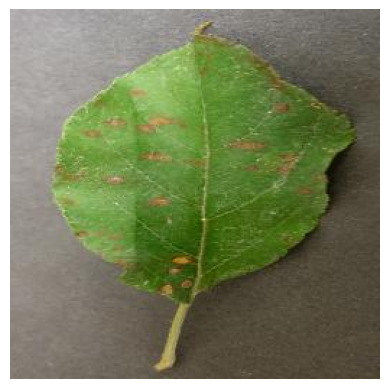

In [20]:
import kagglehub
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# 1. Get the base path where kagglehub actually stored the data
base_path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

# 2. Build the CORRECT path for your Windows PC
# We go from base_path -> 'plantvillage dataset' -> 'color' -> folder -> image
image_folder = os.path.join(base_path, "plantvillage dataset", "color", "Apple___Cedar_apple_rust")
image_file = "025b2b9a-0ec4-4132-96ac-7f2832d0db4a___FREC_C.Rust 3655.JPG"
full_image_path = os.path.join(image_folder, image_file)

# 3. Check if the file exists before reading
if os.path.exists(full_image_path):
    img = mpimg.imread(full_image_path)
    print(f"Image loaded! Shape: {img.shape}")
    plt.imshow(img)
    plt.axis('off') # Hide the x/y numbers
    plt.show()
else:
    print("File not found! Let's check the folder contents:")
    # This helps you see if the file name has a tiny typo
    if os.path.exists(image_folder):
        print(os.listdir(image_folder)[:5]) 
    else:
        print(f"The folder {image_folder} does not exist.")

Success! Image shape: (256, 256, 3)


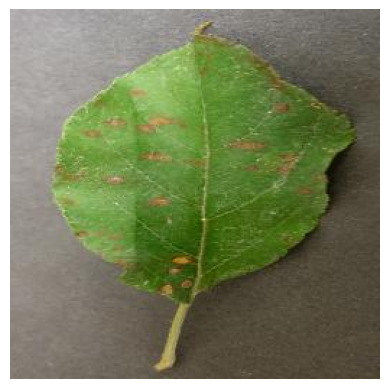

In [22]:
import kagglehub
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# 1. Get the real base path where kagglehub stored the data on your PC
base_path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

# 2. Build the CORRECT path for Windows
# We use os.path.join to handle the backslashes (\) correctly for your system
image_folder = os.path.join(base_path, "plantvillage dataset", "color", "Apple___Cedar_apple_rust")
image_file = "025b2b9a-0ec4-4132-96ac-7f2832d0db4a___FREC_C.Rust 3655.JPG"
full_image_path = os.path.join(image_folder, image_file)

# 3. Read and Display
if os.path.exists(full_image_path):
    img = mpimg.imread(full_image_path)
    print(f"Success! Image shape: {img.shape}")
    plt.imshow(img)
    plt.axis('off')
    plt.show()
else:
    print("File still not found. Let's list the first 5 files in that folder to check the name:")
    if os.path.exists(image_folder):
        print(os.listdir(image_folder)[:5])
    else:
        print("The folder path itself is incorrect. Check your base_path.")

In [23]:
# Image Parameters
img_size = 224
batch_size = 32

**Train Test Split**

In [24]:
# Image Data Generators
data_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # Use 20% of data for validation
)

In [26]:
import kagglehub
import os

# 1. Get the actual "hidden" path where the data is stored
true_base_path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

# 2. Correctly join the subfolders for your specific project
# This builds: C:\Users\syed aafreen\.cache\...\plantvillage dataset\color
base_dir = os.path.join(true_base_path, "plantvillage dataset", "color")

# 3. Double-check if the path is valid before running the generator
if os.path.exists(base_dir):
    print("Found the data! Path is:", base_dir)
    print("Categories found:", len(os.listdir(base_dir)))
else:
    print("Error: Path still not found. Check the folder names inside true_base_path.")

Found the data! Path is: C:\Users\syed aafreen\.cache\kagglehub\datasets\abdallahalidev\plantvillage-dataset\versions\3\plantvillage dataset\color
Categories found: 38


In [27]:
# Validation Generator
validation_generator = data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='validation',
    class_mode='categorical'
)

Found 10849 images belonging to 38 classes.


In [35]:
# Training Generator
train_generator = data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='training',
    class_mode='categorical'
)

Found 43456 images belonging to 38 classes.


**Convolutional Neural Network**

In [31]:
# Model Definition
model = models.Sequential()

# Layer 1
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)))
model.add(layers.MaxPooling2D(2, 2))

# Layer 2
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D(2, 2))

# Flatten and Dense Layers
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))

# Use the actual number 38 if 'train_generator.num_classes' gives an error
model.add(layers.Dense(38, activation='softmax')) 

# IMPORTANT: You must compile the model next!
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │    47,776,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,805,158 (182.36 MB)

 Trainable params: 47,805,158 (182.36 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# model summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │    47,776,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,805,158 (182.36 MB)

 Trainable params: 47,805,158 (182.36 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# Compile the Model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

**Model training**

In [36]:
# Training the Model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,  # Number of steps per epoch
    epochs=5,  # Number of epochs
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size  # Validation steps
)

C:\Users\syed aafreen\AppData\Roaming\Python\Python39\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 3452s 3s/step - accuracy: 0.6182 - loss: 1.6026 - val_accuracy: 0.8620 - val_loss: 0.4433
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 2578s 2s/step - accuracy: 0.9151 - loss: 0.2653 - val_accuracy: 0.8866 - val_loss: 0.3541
Epoch 3/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 2526s 2s/step - accuracy: 0.9611 - loss: 0.1177 - val_accuracy: 0.8732 - val_loss: 0.4455
Epoch 4/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 3465s 3s/step - accuracy: 0.9779 - loss: 0.0718 - val_accuracy: 0.8606 - val_loss: 0.5519
Epoch 5/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 2630s 2s/step - accuracy: 0.9812 - loss: 0.0581 - val_accuracy: 0.8621 - val_loss: 0.6257


**Model Evaluation**

In [37]:
# Model Evaluation
print("Evaluating model...")
val_loss, val_accuracy = model.evaluate(validation_generator, steps=validation_generator.samples // batch_size)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

Evaluating model...
339/339 ━━━━━━━━━━━━━━━━━━━━ 103s 295ms/step - accuracy: 0.8556 - loss: 0.6579
Validation Accuracy: 86.22%


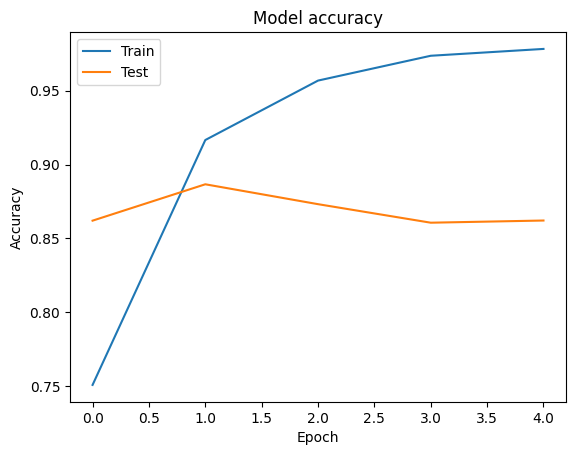

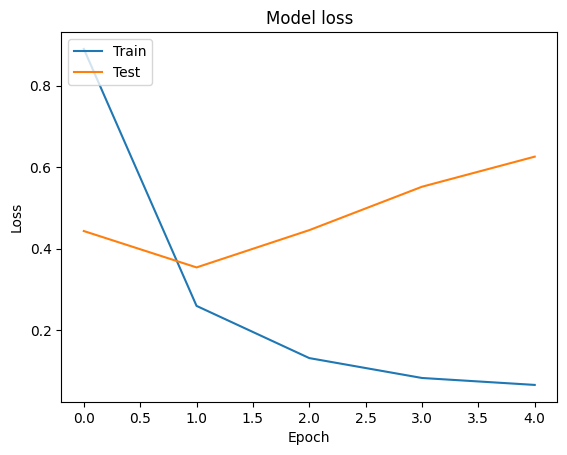

In [38]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

**Building a Predictive System**

In [39]:
# Function to Load and Preprocess the Image using Pillow
def load_and_preprocess_image(image_path, target_size=(224, 224)):
    # Load the image
    img = Image.open(image_path)
    # Resize the image
    img = img.resize(target_size)
    # Convert the image to a numpy array
    img_array = np.array(img)
    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)
    # Scale the image values to [0, 1]
    img_array = img_array.astype('float32') / 255.
    return img_array

# Function to Predict the Class of an Image
def predict_image_class(model, image_path, class_indices):
    preprocessed_img = load_and_preprocess_image(image_path)
    predictions = model.predict(preprocessed_img)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_class_name = class_indices[predicted_class_index]
    return predicted_class_name

In [40]:
# Create a mapping from class indices to class names
class_indices = {v: k for k, v in train_generator.class_indices.items()}

In [41]:
class_indices

{0: 'Apple___Apple_scab',
 1: 'Apple___Black_rot',
 2: 'Apple___Cedar_apple_rust',
 3: 'Apple___healthy',
 4: 'Blueberry___healthy',
 5: 'Cherry_(including_sour)___Powdery_mildew',
 6: 'Cherry_(including_sour)___healthy',
 7: 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 8: 'Corn_(maize)___Common_rust_',
 9: 'Corn_(maize)___Northern_Leaf_Blight',
 10: 'Corn_(maize)___healthy',
 11: 'Grape___Black_rot',
 12: 'Grape___Esca_(Black_Measles)',
 13: 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 14: 'Grape___healthy',
 15: 'Orange___Haunglongbing_(Citrus_greening)',
 16: 'Peach___Bacterial_spot',
 17: 'Peach___healthy',
 18: 'Pepper,_bell___Bacterial_spot',
 19: 'Pepper,_bell___healthy',
 20: 'Potato___Early_blight',
 21: 'Potato___Late_blight',
 22: 'Potato___healthy',
 23: 'Raspberry___healthy',
 24: 'Soybean___healthy',
 25: 'Squash___Powdery_mildew',
 26: 'Strawberry___Leaf_scorch',
 27: 'Strawberry___healthy',
 28: 'Tomato___Bacterial_spot',
 29: 'Tomato___Early_blight',
 30: '

In [42]:
# saving the class names as json file
json.dump(class_indices, open('class_indices.json', 'w'))

In [45]:
import os
import kagglehub
import numpy as np
from PIL import Image

# 1. Get the latest path from kagglehub
base_path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

# 2. Automatically find the FIRST image in the Apple___Apple_scab folder
# This avoids typos in the long filename
target_folder = os.path.join(base_path, "plantvillage dataset", "color", "Apple___Apple_scab")

if os.path.exists(target_folder):
    # Get a list of all files in that folder and pick the first one
    all_images = [f for f in os.listdir(target_folder) if f.endswith('.JPG')]
    if all_images:
        image_path = os.path.join(target_folder, all_images[0])
        print(f"Using actual image: {image_path}")
        
        # 3. Run the prediction
        # Make sure 'class_indices' is defined from your generator!
        predicted_class_name = predict_image_class(model, image_path, class_indices)
        print("Predicted Class Name:", predicted_class_name)
    else:
        print("The folder exists but no .JPG files were found inside.")
else:
    print(f"Error: Folder not found at {target_folder}. Check the 'versions' folder number.")

Using actual image: C:\Users\syed aafreen\.cache\kagglehub\datasets\abdallahalidev\plantvillage-dataset\versions\3\plantvillage dataset\color\Apple___Apple_scab\00075aa8-d81a-4184-8541-b692b78d398a___FREC_Scab 3335.JPG
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step
Predicted Class Name: Apple___Apple_scab


**Save the model to Google drive or local**

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


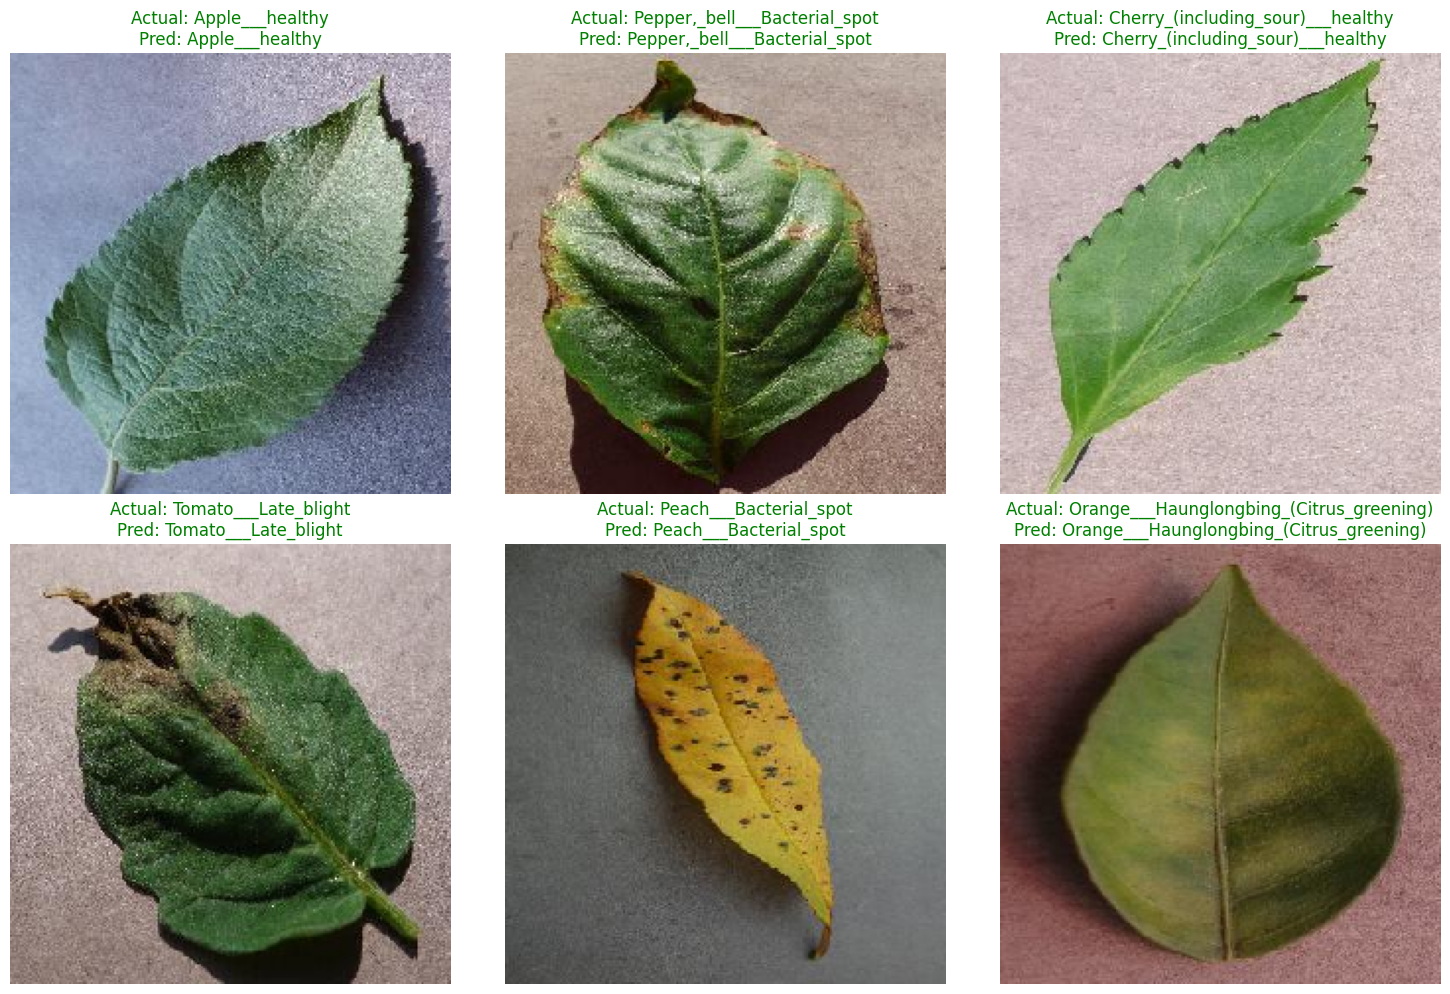

In [48]:
import matplotlib.pyplot as plt

# 1. Get a batch of images and labels from the validation generator
# This pulls the next 32 images (one batch)
val_images, val_labels = next(validation_generator)

# 2. Get the class names (keys) from the dictionary
class_names = list(train_generator.class_indices.keys())

# 3. Predict the whole batch
predictions = model.predict(val_images)

# 4. Plot 6 images to see how it's doing
plt.figure(figsize=(15, 10))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(val_images[i])
    
    # Get the actual class and predicted class
    actual_class = class_names[np.argmax(val_labels[i])]
    predicted_class = class_names[np.argmax(predictions[i])]
    
    # Set title color: Green if correct, Red if wrong
    title_color = 'green' if actual_class == predicted_class else 'red'
    
    plt.title(f"Actual: {actual_class}\nPred: {predicted_class}", color=title_color)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [49]:
list(train_generator.class_indices.keys())

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_